# Lnaggraph 활용 Agent 구축

### 1. bind tools
### 2. create agent
### 3. create retriever tool
```python
from langchain_core.retrievers import BaseRetriever
from langchain_core.prompts import BasePromptTemplate
from typing import Literal

def create_retriever_tool(
    retriever: BaseRetriever,
    name: str,
    description: str,
    *,
    document_prompt: BasePromptTemplate | None = None,
    document_separator: str = "\n\n",
    response_format: Literal["content", "content_and_artifact"] = "content",
):
```

어떤 상황에서 이 툴을 써야 하는지 정의하는것은 description이고, 가져온 문서들을 LLM에게 어떻게 보여줄지는 document_prompt라고 생각할 수 있다.

- response_format: 
"content" (기본값)
Retriever가 찾은 문서 내용만 반환합니다. document_prompt로 포맷팅된 텍스트만 Agent에게 전달됩니다.

"content_and_artifact"
포맷팅된 문서 내용 + 메타데이터를 함께 반환합니다


---
ReAct 과정의 차이입니다. 
- bind_tools는 단일 턴(turn)만 처리하며 개발자가 직접 추론(Reasoning)→행동(Acting)→관찰(Observation) 사이클을 구현해야 합니다. 
- 반면 create_agent는 ReAct 패턴을 자동으로 구현하여 LLM이 문제를 해결할 때까지 Think→Act→Observe 루프를 자동으로 반복합니다

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [2]:
from langchain_tavily import tavily_search, TavilySearch

tavily = TavilySearch(
    name="tavily_web_search",
    description=(
        "일상적인 대화나, 사용할 도구가 없다면, tavily를 이용하세요"
    ),
)
tools = [tavily]

tavily.invoke("테디노트 랭체인 튜토리얼")

{'query': '테디노트 랭체인 튜토리얼',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.youtube.com/watch?v=mVu6Wj8Z7C0',
   'title': '랭체인 한국어 튜토리얼     업데이트 소식   처음 사용자를 위한 친절한 ...',
   'content': '#랭체인 한국어 튜토리얼🇰🇷 업데이트 소식🔥 처음 사용자를 위한 친절한 환경설치(Windows, Mac)\n테디노트 TeddyNote\n48400 subscribers\n337 likes\n19315 views\n19 Jun 2024\n📝 환경설정(Windows)\nhttps://teddynote.com/10-RAG%EB%B9%84%EB%B2%95%EB%85%B8%ED%8A%B8/%ED%99%98%EA%B2%BD%20%EC%84%A4%EC%A0%95%20(Windows)/\n\n📝 환경설정(Mac)\nhttps://teddynote.com/10-RAG%EB%B9%84%EB%B2%95%EB%85%B8%ED%8A%B8/%ED%99%98%EA%B2%BD%20%EC%84%A4%EC%A0%95%20(Mac)/\n\n📍[패스트캠퍼스] "테디노트의 RAG 비법노트" 강의\n링크: https://bit.ly/4e1h8zO\n\n🤖 디스코드 채널\nhttps://discord.gg/q3RvQZ5CfK\n\n📘 랭체인 튜토리얼 무료 전자책(wikidocs)\nhttps://wikidocs.net/book/14314\n\n✅ 랭체인 한국어 튜토리얼 코드저장소(GitHub)\nhttps://github.com/teddylee777/langchain-kr\n\n✅ 줄거리\n00:00 랭체인 한국어 튜토리얼 공지사항\n01:59 langchain-teddynote 패키지\n08:25 감사인사\n09:15 Windows 환경설치\n21:48 Mac 환경설치\n\n#rag #la

In [3]:
from RAG.retriever import QdrantRetrieverFactory

qs = QdrantRetrieverFactory()
compression_retriever = qs.compression_retriever(collection_name="RAG_Template", fetch_k=10, top_n=3)
retriever = qs.retriever(collection_name="RAG_Template", fetch_k=3)

In [ ]:
print(retriever.invoke("Agentic-RAG에 대해서 알려줘")[0].page_content)

향후 연구 및 개발 방향으로는 Agentic RAG 시스템의 자동 오류 감지 및 회복 로직 강화, 도 메인 특화 워크플로우의 최적화, 다양한 LLM 및 임베딩 모델의 정량적 성능 평가, 그리고 실시간 사용자 피드백을 반영한 동적 워크플로우 개선 등이 중요하게 제시된다. 즉, RAG와 Agentic RAG 시스템의 성능은 LLM 모델 선택, 텍스트 분할 기법, 임베딩 전략, 그리고 워크플로우의 명확한 상태 관리 및 분기 조건 설계에 의해 결 정된다. 이러한 후속 연구가 이루어진다면, RAG 및 Agentic RAG 시스템의 안정성과 효율성, 그 리고 실질적인 활용 가능성이 더욱 높아질 것으 로 기대된다.

## REFERENCES


In [5]:
# print(compression_retriever.invoke("Agentic-RAG")[0].page_content)

In [6]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_core.tools import create_retriever_tool
# insight_agentic, LangGraph-Based Integrated Architecture for CrewAI Multi-Agent 논문
retriever_tool = create_retriever_tool(retriever, "agentic_rag_papers_retriever", "insight_agentic, LangGraph-Based Integrated Architecture for CrewAI Multi-Agent 논문")
tools = [retriever_tool, tavily]

In [7]:
from RAG.rag import chat_history_rag, rag
rerank_chain = chat_history_rag(retriever)
print(rerank_chain.invoke({"question": "Agentic RAG에 대해서 알려줘", "chat_history":[]}))

Agentic RAG는 기존 Retrieval-Augmented Generation(RAG)의 한계를 극복하기 위해 reflection, planning, tool-use, multi-agent collaboration 등 에이전트 기반 패턴을 도입한 개념이다. 복잡한 멀티스텝 추론, 동적 분기, 도구 호출 등 다양한 워크플로우 설계와 자동 도구 활용이 가능하며, Single Agent Router, Multi-Agent System, Hierarchical/Graph-Based 구조로 구현된다. 사용자의 질문 의도와 문맥을 파악해 필요한 도구를 선택 호출하거나, 복수 에이전트가 협력해 문제를 해결하는 점에서 기존 RAG와 차별화된다.

**Source**  
- docling_outputs\insight_Agentic.pdf.md (1, 2)  
- docling_outputs\LangGraph-Based Integrated Architecture for CrewAI Multi-Agent.pdf.md (3)


In [8]:
from langchain_openai import ChatOpenAI

# LLM 초기화
llm = ChatOpenAI(model="gpt-4.1-nano")

# LLM 에 도구 바인딩
llm_with_tools = llm.bind_tools(tools)
llm_with_tools.invoke("Agentic-RAG")

AIMessage(content='Agentic-RAG, or Agentic-Reactive Augmented Generation, is an advanced AI architecture that integrates agentic features into the retrieval-augmented generation framework. It combines the strengths of reactive information retrieval with agentic decision-making to enhance the capability of AI systems in complex, dynamic environments.\n\nKey features of Agentic-RAG include:\n- Agentic Decision-Making: Enables the system to make autonomous decisions based on retrieved information and ongoing context.\n- Enhanced Retrieval: Utilizes specialized retrievers to fetch relevant data from large corpora, grounding responses in factual information.\n- Reactive and Proactive Responses: Balances reactive information processing with proactive goal-oriented actions.\n- Multi-Agent Collaboration: Supports coordination among multiple agents to accomplish complex tasks.\n\nApplications of Agentic-RAG encompass:\n- Interactive AI Assistants\n- Autonomous Systems\n- Complex Data Analysis\n

In [9]:
llm_with_tools.invoke("랭체인 테디노트에 대해서 알려줘")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1279, 'total_tokens': 1303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_1a97b5aa6c', 'id': 'chatcmpl-CbtqVeVZD9IoyInuHHlA6AzUpSUec', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--3de29ca3-ef6a-4ae8-9fb9-41cde4b4726e-0', tool_calls=[{'name': 'tavily_web_search', 'args': {'query': '랭체인 테디노트'}, 'id': 'call_F0dS8JgcnG3qxhmoufzy38mE', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1279, 'output_tokens': 24, 'total_tokens': 1303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [10]:
tools = [retriever_tool, tavily]
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
prompt = """
retriever 도구는, Design Insight from Empirical Experiences in Implementing Agentic RAG Systems, LangGraph-Based Integrated Architecture for CrewAI Multi-Agent 논문입니다.
논문과 관련된 질문이 들어온다면, retriever 도구를 사용해 주세요.

만약 주어진 질문이 이 논문과 관련이 없다면, tavily 도구를 사용해주세요.
한국어로 답해주세요.
"""
# Fix: Swap the order of arguments per the latest langchain agents API (llm/model, then tools)
retriever_agent = create_agent(llm, tools, system_prompt=prompt)
retriever_agent.invoke({"messages": "Agentic RAG에 대해서 알려줘"})

{'messages': [HumanMessage(content='Agentic RAG에 대해서 알려줘', additional_kwargs={}, response_metadata={}, id='c26697d6-a67d-4e0a-b34e-fccbe92f9f68'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1360, 'total_tokens': 1384, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CbtqWcWzlHQYC8DFv4DnKbyrkqVxB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--b1da9947-ecd7-46d0-9de7-43a19d7dcba3-0', tool_calls=[{'name': 'agentic_rag_papers_retriever', 'args': {'query': 'Agentic RAG'}, 'id': 'call_Abka45rZt2wtu7jw4LrlSiJx', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1360, 'output_

In [11]:
retriever_agent.invoke({"messages": "랭체인 테디노트에 대해서 알려줘"})

{'messages': [HumanMessage(content='랭체인 테디노트에 대해서 알려줘', additional_kwargs={}, response_metadata={}, id='7d95d3f3-f5bc-49fa-8311-e4f1f6a4b0e1'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1364, 'total_tokens': 1388, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CbtqdrlK6dVRdbKMILxPbpVFAlVE4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--a9a00888-62e5-46b3-8903-b5af37ce4429-0', tool_calls=[{'name': 'tavily_web_search', 'args': {'query': '랭체인 테디노트'}, 'id': 'call_ZZnNZ6f93A4rbsr3xNXYS8g5', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1364, 'output_tokens': 24, 'tot

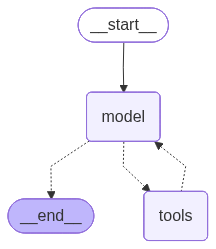

In [12]:
retriever_agent

In [13]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


# State 정의
class State(TypedDict):
    # list 타입에 add_messages 적용(list 에 message 추가)
    messages: Annotated[list, add_messages]

In [14]:
# 노드 함수 정의
def chatbot(state: State):
    answer = retriever_agent.invoke(state["messages"])
    # 메시지 목록 반환
    return {"messages": [answer]}  # 자동으로 add_messages 적용

In [15]:
from langgraph.graph import StateGraph

# 상태 그래프 초기화
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("chatbot", chatbot)

In [16]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langchain_teddynote.tools.tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


########## 1. 상태 정의 ##########
# 상태 정의
class State(TypedDict):
    # 메시지 목록 주석 추가
    messages: Annotated[list, add_messages]


# ########## 2. 도구 정의 및 바인딩 ##########
# # 도구 초기화
# tool = TavilySearch(max_results=3)
# tools = [retriever_tool, tool]

# # LLM 초기화
# llm = ChatOpenAI(model="gpt-4.1-nano")

# # 도구와 LLM 결합
# llm_with_tools = llm.bind_tools(tools)


########## 3. 노드 추가 ##########
# 챗봇 함수 정의
# def chatbot(state: State):
#     # 메시지 호출 및 반환
#     return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 상태 그래프 생성
graph_builder = StateGraph(State)

# 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)

# # 도구 노드 생성 및 추가
# tool_node = ToolNode(tools=[tool])

# # 도구 노드 추가
# graph_builder.add_node("tools", tool_node)

# # 조건부 엣지
# graph_builder.add_conditional_edges(
#     "chatbot",
#     tools_condition,
# )

########## 4. 엣지 추가 ##########

# tools > chatbot
# graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

# chatbot > END
graph_builder.add_edge("chatbot", END)

In [17]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langchain_teddynote.tools.tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# 메모리 저장소 생성
memory = MemorySaver()

########## 1. 상태 정의 ##########
# 상태 정의
class State(TypedDict):
    # 메시지 목록 주석 추가
    messages: Annotated[list, add_messages]


########## 2. 도구 정의 및 바인딩 ##########
# 도구 초기화
tool = TavilySearch(max_results=3)
tools = [tool]

# LLM 초기화
llm = ChatOpenAI(model="gpt-4.1-nano")

# 도구와 LLM 결합
llm_with_tools = llm.bind_tools(tools)


########## 3. 노드 추가 ##########
# 챗봇 함수 정의
def chatbot(state: State):
    # 메시지 호출 및 반환
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 상태 그래프 생성
graph_builder = StateGraph(State)

# 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)

# 도구 노드 생성 및 추가
tool_node = ToolNode(tools=[tool])

# 도구 노드 추가
graph_builder.add_node("tools", tool_node)

# 조건부 엣지
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

########## 4. 엣지 추가 ##########

# tools > chatbot
graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

# chatbot > END
graph_builder.add_edge("chatbot", END)

# 그래프 빌더 컴파일
graph = graph_builder.compile(checkpointer=memory)

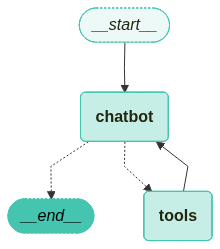

In [18]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph)

In [19]:
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(
    recursion_limit=10,  # 최대 10개의 노드까지 방문. 그 이상은 RecursionError 발생
    configurable={"thread_id": "1"},  # 스레드 ID 설정
)

In [20]:
# 첫 질문
question = (
    "Agentic RAG에 대해서 알려줘"
)

for event in graph.stream({"messages": [("user", question)]}, config=config):
    for value in event.values():
        value["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_KSXxI3rgAsBfmPM1kM3J6BDF)
 Call ID: call_KSXxI3rgAsBfmPM1kM3J6BDF
  Args:
    query: Agentic RAG
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://www.moveworks.com/us/en/resources/blog/what-is-agentic-rag", "title": "A Complete Guide to Agentic RAG - Moveworks", "content": "**Agents are the cornerstone of an agentic RAG framework, functioning as autonomous units that specialize in specific tasks throughout the retrieval and generation pipeline.**These agents collaborate to optimize the system's overall performance, handling functions such as query understanding, information retrieval, response generation, and system management. By leveraging these diverse agents and tools, agentic RAG systems can handle complex queries with greater accuracy and efficiency, adapting to user needs and evolving inf

In [21]:
# 이어지는 질문
question = "이전 질문이 뭐였지?"

for event in graph.stream({"messages": [("user", question)]}, config=config):
    for value in event.values():
        value["messages"][-1].pretty_print()

================================== Ai Message ==================================

이전 질문은 "Agentic RAG에 대해서 알려줘"라는 내용이었습니다.


In [22]:
# 이어지는 질문
question = "랭체인 테디노트가 뭐야?"

for event in graph.stream({"messages": [("user", question)]}, config=config):
    for value in event.values():
        value["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_slzdTgxrU1vu8yEznez0ql5P)
 Call ID: call_slzdTgxrU1vu8yEznez0ql5P
  Args:
    query: 랭체인 테디노트
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://product.kyobobook.co.kr/detail/S000216574552", "title": "테디노트의 랭체인을 활용한 RAG 비법노트(기본편) | 이경록 - 교보문고", "content": "RAG 파이프라인 8단계(문서 로드 → 텍스트 분할 → 임베딩 → 벡터 저장 → 리트리버 검색 → 프롬프트 생성 → LLM 응답 생성 → 체인 구성)를 하나하나 실습하며, 각 단계에서 활용할 수 있는 다양한 모듈과 도구(PDF 로더, 여러 종류의 텍스트 분할기, OpenAI 및 Hugging Face 임베딩, 다양한 벡터 데이터베이스, 고급 리트리버 등)를 익힌다. 책 전반에 걸쳐 LLM 모델(OpenAI, Hugging Face, Upstage, Ollama 등), 문서 로더(PDF, HWP, CSV, 웹 데이터), 텍스트 분할기, 벡터 스토어(Chroma, FAISS, Pinecone), 리트리버, 메모리 시스템 구축 과정을 반복해서 실습한다. | 리워드  지급제외 | - 주문 후 90일 이후 리뷰 작성 건   - 판매가 5,000원 미만 상품 (2024년 9월 30일부터 적용)  - 교보문고: 강연, 공연, 여행, 동영상, 사은품, 기프트카드  - eBook: sam 이용권 구매 상품, 선물 받은 eBook  - 핫트랙스: CD/DVD 상품  - 매장 구매 영수증 